# Exploratory Data Analysis — Synthetic Transaction Dataset

This notebook walks through the synthetic transaction dataset used to train the Financial Risk Intelligence Platform. It covers:

1. **Dataset overview** — shape, dtypes, missing values, summary statistics
2. **Class imbalance** — fraud prevalence and its implications for modelling
3. **Feature distributions** — legitimate vs. fraudulent transaction profiles
4. **Fraud rate by feature** — which features best discriminate fraud
5. **Correlation analysis** — inter-feature relationships
6. **Bivariate analysis** — key feature interactions coloured by fraud label
7. **Key findings** — summary of what the EDA tells us about the modelling approach

---

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Allow imports from the project root
sys.path.insert(0, str(Path().resolve().parent))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.data.loader import load_transactions

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

FRAUD_COLOUR   = '#ef4444'   # red
LEGIT_COLOUR   = '#3b82f6'   # blue
NEUTRAL_COLOUR = '#6366f1'   # indigo

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
df = load_transactions()   # generates 10,000 synthetic transactions if no CSV found

fraud = df[df['is_fraud'] == 1]
legit = df[df['is_fraud'] == 0]

print(f'Total transactions : {len(df):,}')
print(f'Legitimate         : {len(legit):,}  ({len(legit)/len(df):.1%})')
print(f'Fraudulent         : {len(fraud):,}  ({len(fraud)/len(df):.1%})')

No creditcard.csv found — generating synthetic dataset.
Loaded 10,000 transactions | fraud rate: 2.00%
Total transactions : 10,000
Legitimate         : 9,800  (98.0%)
Fraudulent         : 200  (2.0%)


## 3. Dataset Overview

In [3]:
print(f'Shape: {df.shape}\n')
print('Dtypes:')
print(df.dtypes.to_string())

Shape: (10000, 11)

Dtypes:
amount                     float64
hour                         int64
merchant_risk_tier           int64
velocity_1h                  int64
velocity_24h                 int64
high_risk_country            int64
amount_vs_avg_ratio        float64
days_since_account_open      int64
is_weekend                   int64
is_fraud                     int64
transaction_id              object


In [4]:
# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — dataset is complete.')

Missing values per column:
None — dataset is complete.


In [5]:
# Summary statistics split by class
numeric_cols = ['amount', 'hour', 'velocity_1h', 'velocity_24h',
                'amount_vs_avg_ratio', 'days_since_account_open']

summary = df.groupby('is_fraud')[numeric_cols].agg(['mean', 'median', 'std']).T
summary.columns = ['Legitimate', 'Fraud']
summary['Ratio (Fraud/Legit)'] = (summary['Fraud'] / summary['Legitimate']).round(2)
summary.round(2)

Legitimate     Fraud  Ratio (Fraud/Legit)
amount                  mean         68.10   2818.84                41.39
                        median       32.64    253.25                 7.76
                        std         123.30  27438.30               222.53
hour                    mean         14.68      8.77                 0.60
                        median       15.00      5.00                 0.33
                        std           4.60      8.34                 1.81
velocity_1h             mean          1.50      5.10                 3.41
                        median        1.00      5.00                 5.00
                        std           1.23      2.27                 1.85
velocity_24h            mean          8.00     17.91                 2.24
                        median        8.00     18.00                 2.25
                        std           2.84      3.80                 1.34
amount_vs_avg_ratio     mean          1.08      6.74                 6.23
                        median        1.01      4.98                 4.95
                        std           0.44      7.42                16.75
days_since_account_open mean       1017.13     94.00                 0.09
                        median     1015.00     90.50                 0.09
                        std         573.10     50.62                 0.09

---
## 4. Class Imbalance Analysis

Class imbalance is a defining challenge for fraud detection. Standard accuracy is misleading — a model predicting "legitimate" for every transaction achieves ~98% accuracy while catching zero fraud.

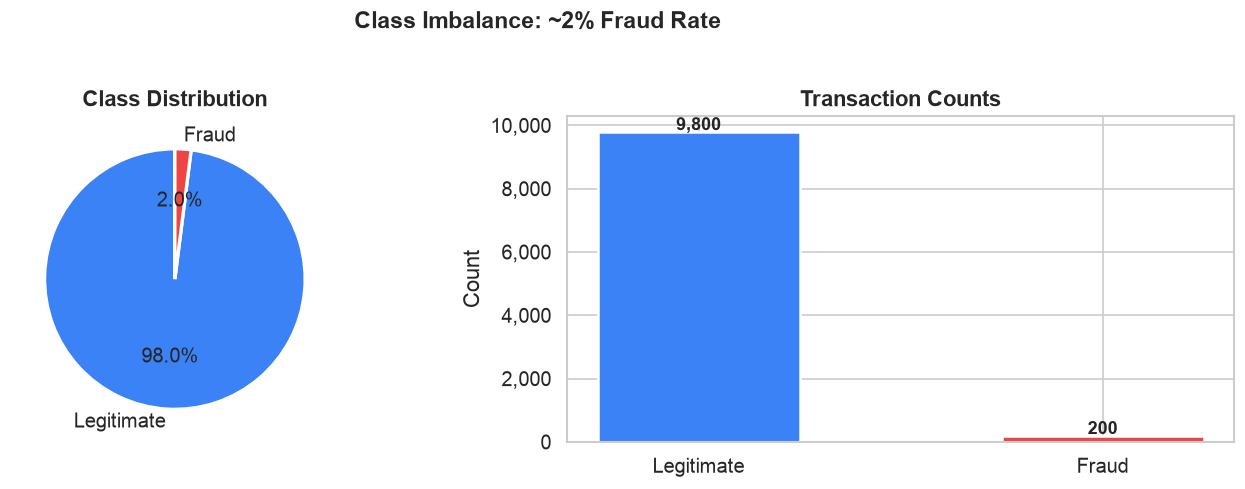

Imbalance ratio: 49:1  (legitimate:fraud)

Implication: Standard accuracy is uninformative. We evaluate using AUC-PR
(area under the precision-recall curve), which is sensitive to minority class performance.
A naive "predict all legitimate" baseline scores AUC-PR ≈ 0.020.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = df['is_fraud'].value_counts()
axes[0].pie(
    counts,
    labels=['Legitimate', 'Fraud'],
    colors=[LEGIT_COLOUR, FRAUD_COLOUR],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12},
)
axes[0].set_title('Class Distribution', fontweight='bold')

# Bar chart with counts
bars = axes[1].bar(
    ['Legitimate', 'Fraud'],
    [len(legit), len(fraud)],
    color=[LEGIT_COLOUR, FRAUD_COLOUR],
    edgecolor='white', linewidth=1.5, width=0.5,
)
for bar, count in zip(bars, [len(legit), len(fraud)]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{count:,}',
        ha='center', fontsize=11, fontweight='bold',
    )
axes[1].set_title('Transaction Counts', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Class Imbalance: ~2% Fraud Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

imbalance_ratio = len(legit) / len(fraud)
print(f'Imbalance ratio: {imbalance_ratio:.0f}:1  (legitimate:fraud)')
print()
print('Implication: Standard accuracy is uninformative. We evaluate using AUC-PR')
print('(area under the precision-recall curve), which is sensitive to minority class performance.')
print(f'A naive "predict all legitimate" baseline scores AUC-PR ≈ {len(fraud)/len(df):.3f}.')

---
## 5. Feature Distributions — Legitimate vs Fraud

For each continuous feature we compare the distribution across both classes. Wider separation = stronger discriminative signal.

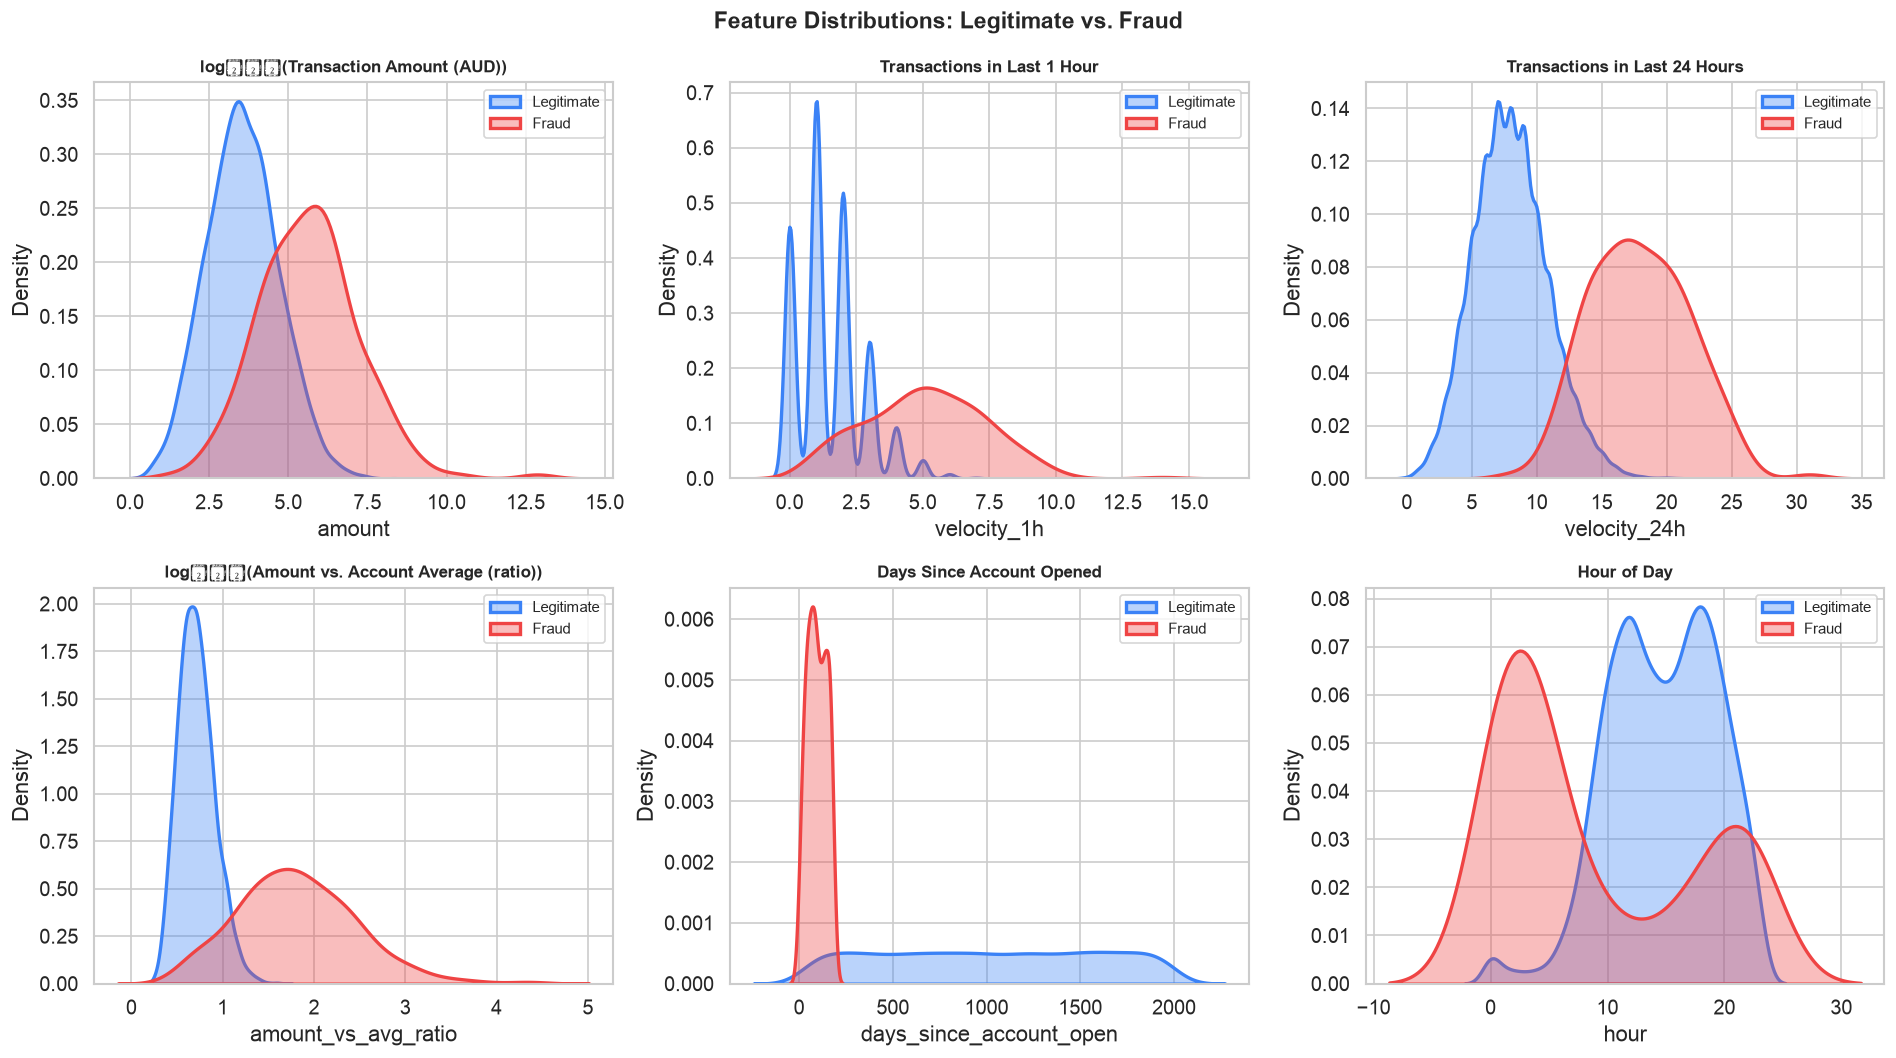

In [7]:
continuous_features = [
    ('amount',                 'Transaction Amount (AUD)',          True),
    ('velocity_1h',            'Transactions in Last 1 Hour',       False),
    ('velocity_24h',           'Transactions in Last 24 Hours',     False),
    ('amount_vs_avg_ratio',    'Amount vs. Account Average (ratio)',True),
    ('days_since_account_open','Days Since Account Opened',         False),
    ('hour',                   'Hour of Day',                       False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, label, log_scale) in zip(axes, continuous_features):
    for cls, colour, name in [
        (0, LEGIT_COLOUR, 'Legitimate'),
        (1, FRAUD_COLOUR, 'Fraud'),
    ]:
        data = df[df['is_fraud'] == cls][col]
        if log_scale:
            data = np.log1p(data)
        sns.kdeplot(data, ax=ax, color=colour, label=name, fill=True, alpha=0.35, linewidth=2)

    ax.set_title(('log₁₊₁(' if log_scale else '') + label + (')' if log_scale else ''),
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions: Legitimate vs. Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Fraud Rate by Feature

How does fraud prevalence change across feature values? This reveals the most discriminative features.

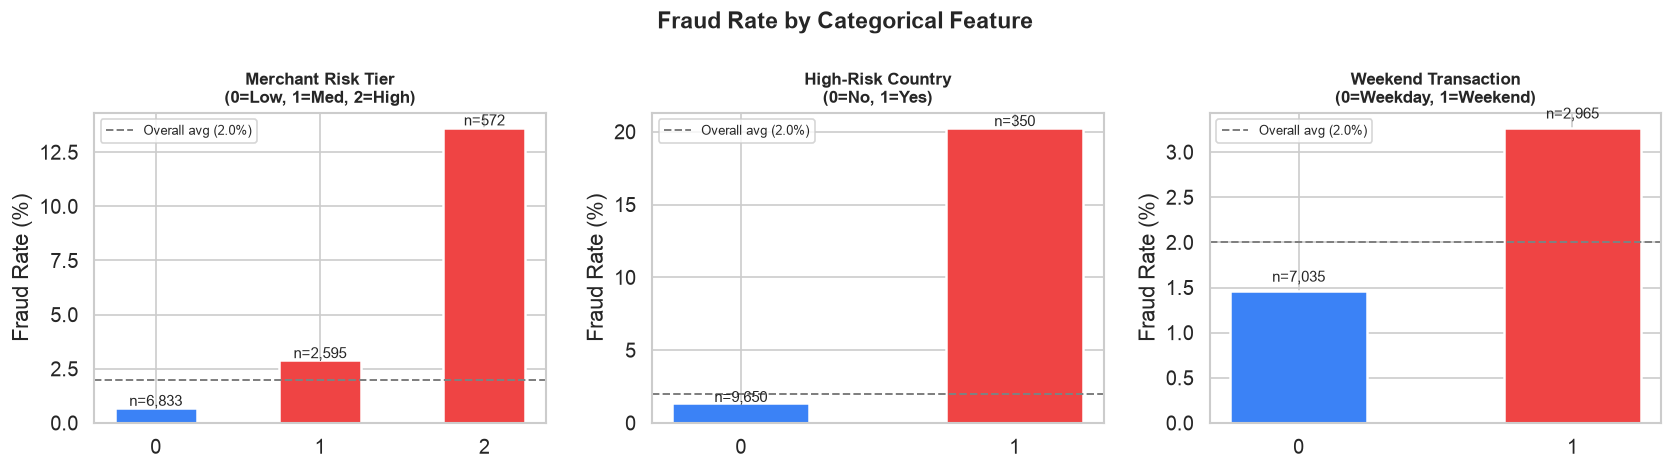

In [8]:
# --- Categorical / ordinal features ---
cat_features = [
    ('merchant_risk_tier',  'Merchant Risk Tier\n(0=Low, 1=Med, 2=High)'),
    ('high_risk_country',   'High-Risk Country\n(0=No, 1=Yes)'),
    ('is_weekend',          'Weekend Transaction\n(0=Weekday, 1=Weekend)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, label) in zip(axes, cat_features):
    fraud_rate = df.groupby(col)['is_fraud'].mean() * 100
    counts = df[col].value_counts().sort_index()
    colours = [FRAUD_COLOUR if r > df['is_fraud'].mean() * 100 else LEGIT_COLOUR
               for r in fraud_rate]
    bars = ax.bar(fraud_rate.index.astype(str), fraud_rate.values, color=colours,
                  edgecolor='white', linewidth=1.5, width=0.5)
    # Add count annotations
    for bar, (idx, cnt) in zip(bars, counts.items()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                f'n={cnt:,}', ha='center', fontsize=9)
    ax.axhline(df['is_fraud'].mean() * 100, color='grey', linestyle='--',
               linewidth=1.2, label=f'Overall avg ({df["is_fraud"].mean():.1%})')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_ylabel('Fraud Rate (%)')
    ax.legend(fontsize=8)

plt.suptitle('Fraud Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

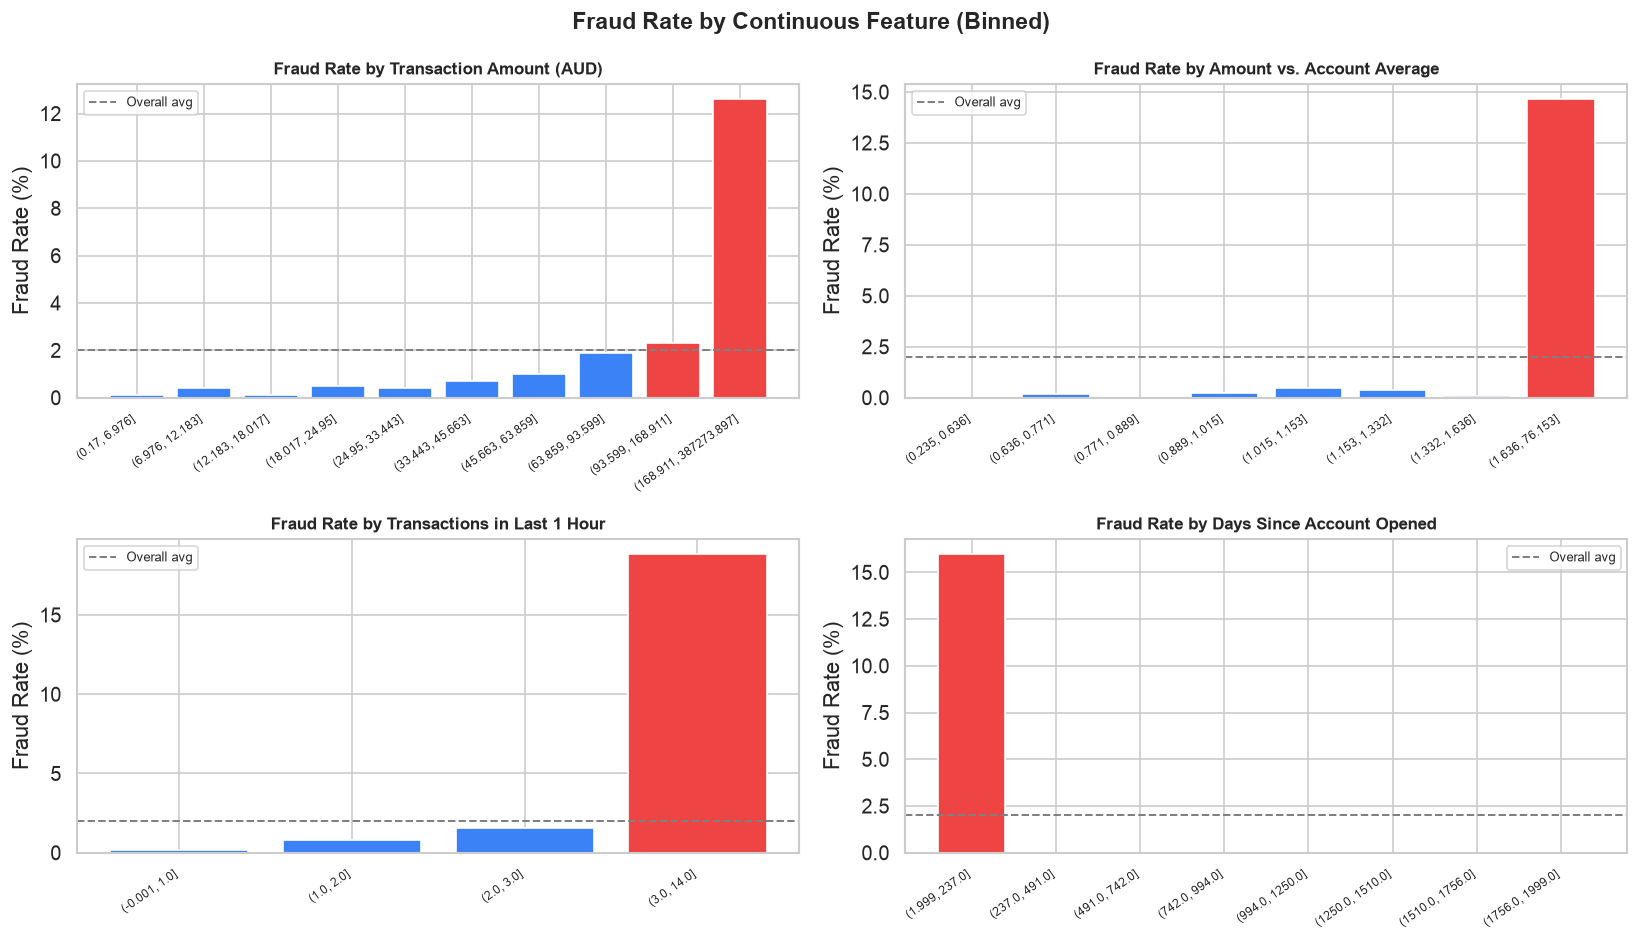

In [9]:
# --- Continuous features: binned fraud rate ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

bin_features = [
    ('amount',             'Transaction Amount (AUD)', 10),
    ('amount_vs_avg_ratio','Amount vs. Account Average', 8),
    ('velocity_1h',        'Transactions in Last 1 Hour', 8),
    ('days_since_account_open', 'Days Since Account Opened', 8),
]

for ax, (col, label, n_bins) in zip(axes, bin_features):
    df['_bin'] = pd.qcut(df[col], q=n_bins, duplicates='drop')
    binned = df.groupby('_bin', observed=True)['is_fraud'].agg(['mean', 'count']).reset_index()
    binned['mean'] *= 100

    colours = [FRAUD_COLOUR if r > df['is_fraud'].mean() * 100 else LEGIT_COLOUR
               for r in binned['mean']]
    ax.bar(range(len(binned)), binned['mean'], color=colours, edgecolor='white', linewidth=1)
    ax.axhline(df['is_fraud'].mean() * 100, color='grey', linestyle='--',
               linewidth=1.2, label='Overall avg')
    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels(
        [str(b) for b in binned['_bin']],
        rotation=35, ha='right', fontsize=7,
    )
    ax.set_title(f'Fraud Rate by {label}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Fraud Rate (%)')
    ax.legend(fontsize=8)

df.drop(columns=['_bin'], inplace=True)
plt.suptitle('Fraud Rate by Continuous Feature (Binned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

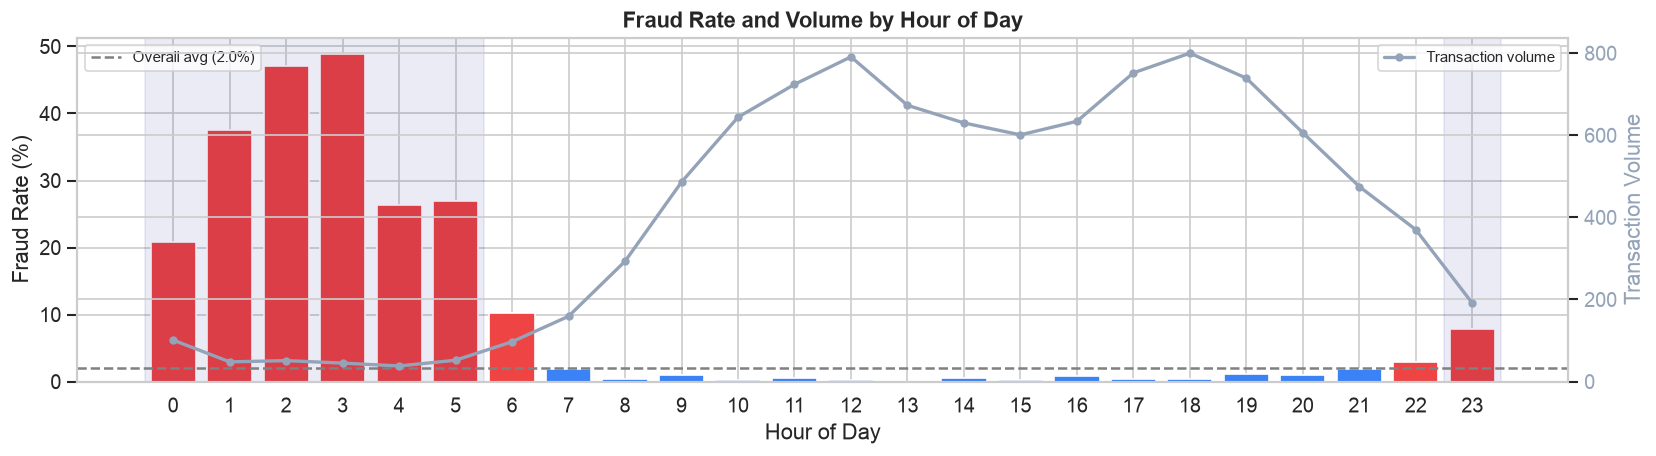

Night window (11pm–5am) fraud rate: 23.6%
Daytime (6am–10pm) fraud rate     : 0.8%
Uplift                             : 29.4x


In [10]:
# --- Hour of day: fraud rate by hour ---
hourly = df.groupby('hour')['is_fraud'].agg(['mean', 'count']).reset_index()
hourly['mean'] *= 100
overall_rate = df['is_fraud'].mean() * 100

fig, ax1 = plt.subplots(figsize=(14, 4))
colours = [FRAUD_COLOUR if r > overall_rate else LEGIT_COLOUR for r in hourly['mean']]
bars = ax1.bar(hourly['hour'], hourly['mean'], color=colours, edgecolor='white', linewidth=1)
ax1.axhline(overall_rate, color='grey', linestyle='--', linewidth=1.5, label=f'Overall avg ({overall_rate:.1f}%)')

# Volume overlay
ax2 = ax1.twinx()
ax2.plot(hourly['hour'], hourly['count'], color='#94a3b8', linewidth=2,
         marker='o', markersize=4, label='Transaction volume')
ax2.set_ylabel('Transaction Volume', color='#94a3b8')
ax2.tick_params(axis='y', labelcolor='#94a3b8')

ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Fraud Rate (%)')
ax1.set_title('Fraud Rate and Volume by Hour of Day', fontsize=13, fontweight='bold')
ax1.set_xticks(range(24))
ax1.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

# Shade the night window (23:00–05:00)
ax1.axvspan(-0.5, 5.5, alpha=0.08, color='navy', label='Night window (11pm–5am)')
ax1.axvspan(22.5, 23.5, alpha=0.08, color='navy')

plt.tight_layout()
plt.show()

night_hours = [23, 0, 1, 2, 3, 4, 5]
night_rate = df[df['hour'].isin(night_hours)]['is_fraud'].mean() * 100
day_rate   = df[~df['hour'].isin(night_hours)]['is_fraud'].mean() * 100
print(f'Night window (11pm–5am) fraud rate: {night_rate:.1f}%')
print(f'Daytime (6am–10pm) fraud rate     : {day_rate:.1f}%')
print(f'Uplift                             : {night_rate/day_rate:.1f}x')

---
## 7. Amount Distribution Deep Dive

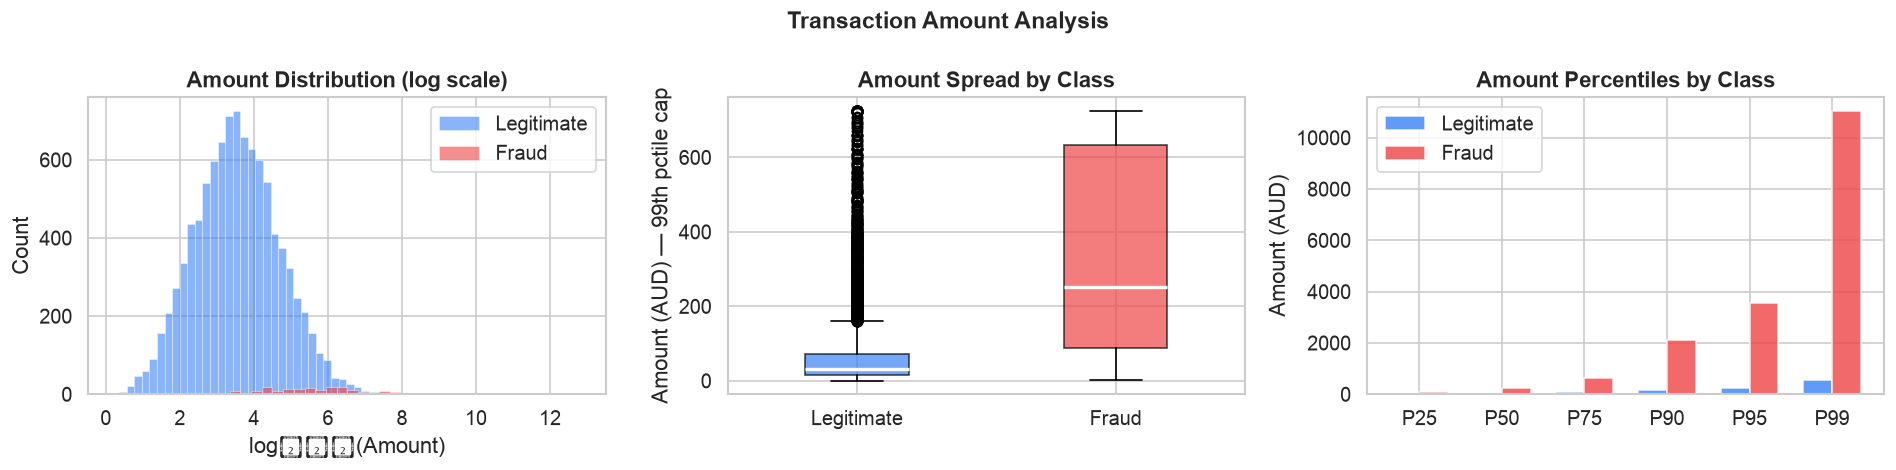

Median legitimate amount : AUD 33
Median fraud amount      : AUD 253
Fraud/Legit median ratio : 7.8x


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Log-scale histogram
for cls, colour, name in [(0, LEGIT_COLOUR, 'Legitimate'), (1, FRAUD_COLOUR, 'Fraud')]:
    axes[0].hist(
        np.log1p(df[df['is_fraud'] == cls]['amount']),
        bins=40, color=colour, alpha=0.6, label=name, edgecolor='white', linewidth=0.4,
    )
axes[0].set_xlabel('log₁₊₁(Amount)')
axes[0].set_ylabel('Count')
axes[0].set_title('Amount Distribution (log scale)', fontweight='bold')
axes[0].legend()

# Box plot
plot_data = [
    df[df['is_fraud'] == 0]['amount'].clip(upper=df['amount'].quantile(0.99)),
    df[df['is_fraud'] == 1]['amount'].clip(upper=df['amount'].quantile(0.99)),
]
bp = axes[1].boxplot(plot_data, patch_artist=True, widths=0.4,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, colour in zip(bp['boxes'], [LEGIT_COLOUR, FRAUD_COLOUR]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_ylabel('Amount (AUD) — 99th pctile cap')
axes[1].set_title('Amount Spread by Class', fontweight='bold')

# Percentile comparison
pcts = [25, 50, 75, 90, 95, 99]
legit_pcts = np.percentile(legit['amount'], pcts)
fraud_pcts = np.percentile(fraud['amount'], pcts)
x = np.arange(len(pcts))
w = 0.35
axes[2].bar(x - w/2, legit_pcts, w, label='Legitimate', color=LEGIT_COLOUR, alpha=0.8)
axes[2].bar(x + w/2, fraud_pcts, w, label='Fraud',      color=FRAUD_COLOUR, alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'P{p}' for p in pcts])
axes[2].set_ylabel('Amount (AUD)')
axes[2].set_title('Amount Percentiles by Class', fontweight='bold')
axes[2].legend()

plt.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Median legitimate amount : AUD {legit["amount"].median():,.0f}')
print(f'Median fraud amount      : AUD {fraud["amount"].median():,.0f}')
print(f'Fraud/Legit median ratio : {fraud["amount"].median() / legit["amount"].median():.1f}x')

---
## 8. Correlation Analysis

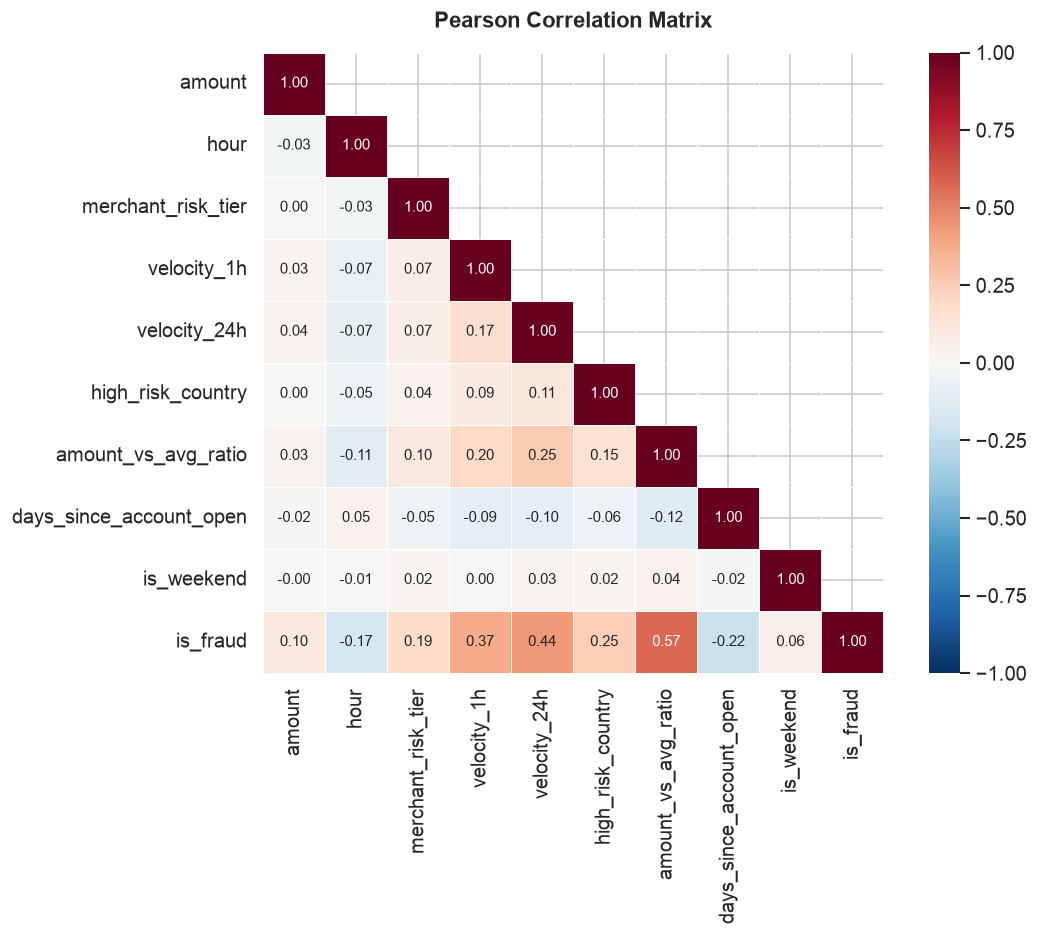

In [12]:
# Correlation heatmap — full feature set
corr_cols = [
    'amount', 'hour', 'merchant_risk_tier', 'velocity_1h', 'velocity_24h',
    'high_risk_country', 'amount_vs_avg_ratio', 'days_since_account_open',
    'is_weekend', 'is_fraud',
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper triangle mask
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    ax=ax,
)
ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

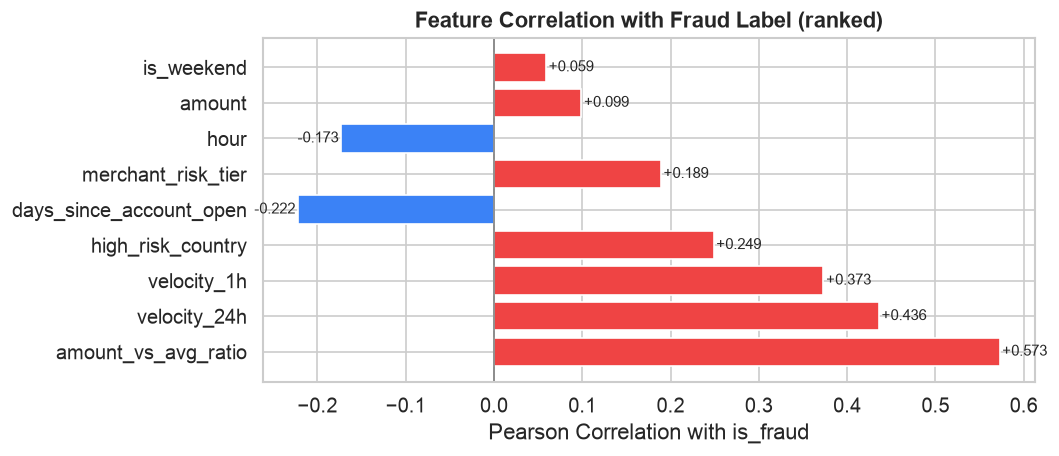

Top 3 features correlated with fraud:
  amount_vs_avg_ratio           : +0.573  (positively correlated)
  velocity_24h                  : +0.436  (positively correlated)
  velocity_1h                   : +0.373  (positively correlated)


In [13]:
# Feature correlations with is_fraud (ranked)
fraud_corr = corr['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colours = [FRAUD_COLOUR if v > 0 else LEGIT_COLOUR for v in fraud_corr.values]
bars = ax.barh(fraud_corr.index, fraud_corr.values, color=colours, edgecolor='white')
ax.axvline(0, color='grey', linewidth=1)
for bar, val in zip(bars, fraud_corr.values):
    ax.text(
        val + (0.003 if val >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9,
    )
ax.set_xlabel('Pearson Correlation with is_fraud')
ax.set_title('Feature Correlation with Fraud Label (ranked)', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 3 features correlated with fraud:')
for feat, val in fraud_corr.head(3).items():
    direction = 'positively' if val > 0 else 'negatively'
    print(f'  {feat:30s}: {val:+.3f}  ({direction} correlated)')

---
## 9. Bivariate Analysis — Key Feature Interactions

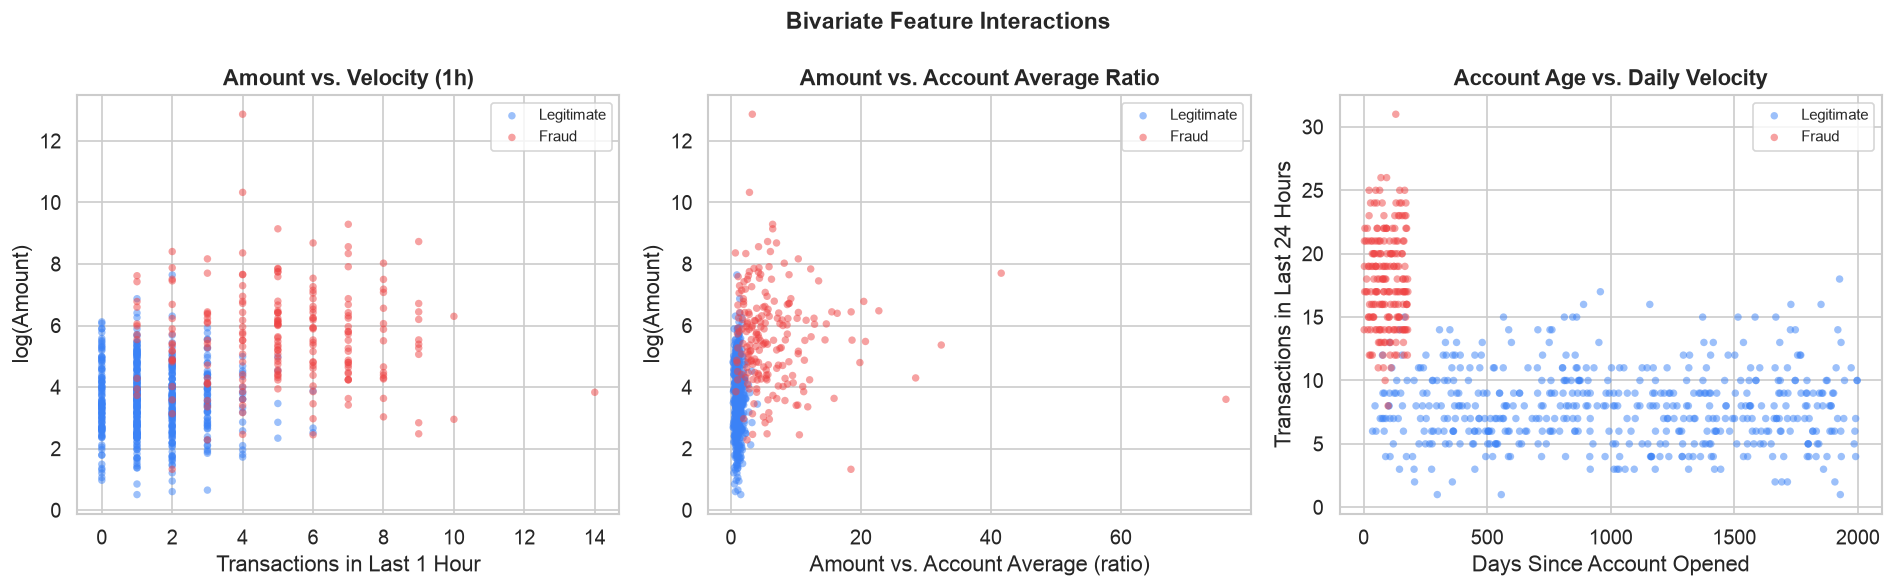

In [14]:
# Sample to avoid overplotting (retain all fraud points)
legit_sample = legit.sample(n=min(500, len(legit)), random_state=42)
plot_df = pd.concat([legit_sample, fraud]).copy()
plot_df['label'] = plot_df['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})

palette = {'Legitimate': LEGIT_COLOUR, 'Fraud': FRAUD_COLOUR}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Amount vs. velocity_1h
for label, colour in palette.items():
    subset = plot_df[plot_df['label'] == label]
    axes[0].scatter(
        subset['velocity_1h'], np.log1p(subset['amount']),
        c=colour, label=label, alpha=0.5, s=20, edgecolors='none',
    )
axes[0].set_xlabel('Transactions in Last 1 Hour')
axes[0].set_ylabel('log(Amount)')
axes[0].set_title('Amount vs. Velocity (1h)', fontweight='bold')
axes[0].legend(fontsize=9)

# Amount vs. amount_vs_avg_ratio
for label, colour in palette.items():
    subset = plot_df[plot_df['label'] == label]
    axes[1].scatter(
        subset['amount_vs_avg_ratio'], np.log1p(subset['amount']),
        c=colour, label=label, alpha=0.5, s=20, edgecolors='none',
    )
axes[1].set_xlabel('Amount vs. Account Average (ratio)')
axes[1].set_ylabel('log(Amount)')
axes[1].set_title('Amount vs. Account Average Ratio', fontweight='bold')
axes[1].legend(fontsize=9)

# Days since open vs. velocity_24h
for label, colour in palette.items():
    subset = plot_df[plot_df['label'] == label]
    axes[2].scatter(
        subset['days_since_account_open'], subset['velocity_24h'],
        c=colour, label=label, alpha=0.5, s=20, edgecolors='none',
    )
axes[2].set_xlabel('Days Since Account Opened')
axes[2].set_ylabel('Transactions in Last 24 Hours')
axes[2].set_title('Account Age vs. Daily Velocity', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Bivariate Feature Interactions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

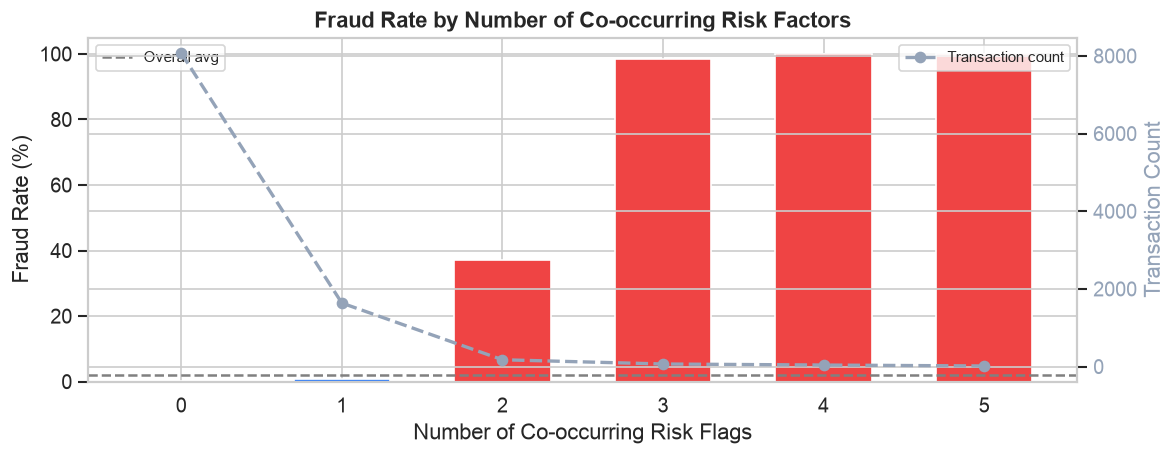

Fraud rate by number of co-occurring risk flags:
  0 flags:   0.0% fraud rate  (n=8,070)
  1 flags:   0.8% fraud rate  (n=1,635)
  2 flags:  37.1% fraud rate  (n=175)
  3 flags:  98.5% fraud rate  (n=66)
  4 flags: 100.0% fraud rate  (n=39)
  5 flags: 100.0% fraud rate  (n=15)


In [15]:
# Multi-flag analysis: what happens when multiple risk factors co-occur?
df['n_risk_flags'] = (
    (df['high_risk_country'] == 1).astype(int)
    + (df['merchant_risk_tier'] == 2).astype(int)
    + (df['hour'].isin([23, 0, 1, 2, 3, 4, 5])).astype(int)
    + (df['velocity_1h'] >= 4).astype(int)
    + (df['amount_vs_avg_ratio'] >= 3).astype(int)
)

multi_flag = df.groupby('n_risk_flags')['is_fraud'].agg(['mean', 'count']).reset_index()
multi_flag['mean'] *= 100

fig, ax1 = plt.subplots(figsize=(10, 4))
colours = [FRAUD_COLOUR if r > df['is_fraud'].mean() * 100 else LEGIT_COLOUR
           for r in multi_flag['mean']]
ax1.bar(multi_flag['n_risk_flags'], multi_flag['mean'], color=colours,
        edgecolor='white', width=0.6)
ax1.axhline(df['is_fraud'].mean() * 100, color='grey', linestyle='--',
            linewidth=1.5, label='Overall avg')
ax1.set_xlabel('Number of Co-occurring Risk Flags')
ax1.set_ylabel('Fraud Rate (%)')
ax1.set_title('Fraud Rate by Number of Co-occurring Risk Factors', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(multi_flag['n_risk_flags'], multi_flag['count'], 'o--',
         color='#94a3b8', linewidth=2, markersize=6, label='Transaction count')
ax2.set_ylabel('Transaction Count', color='#94a3b8')
ax2.tick_params(axis='y', labelcolor='#94a3b8')

ax1.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print('Fraud rate by number of co-occurring risk flags:')
for _, row in multi_flag.iterrows():
    print(f'  {int(row["n_risk_flags"])} flags: {row["mean"]:5.1f}% fraud rate  (n={int(row["count"]):,})')

---
## 10. Key Findings

The EDA reveals a coherent, realistic fraud pattern in the synthetic data and informs the modelling choices made in the platform.

In [16]:
# Quantified findings summary

night_uplift    = df[df['hour'].isin([23,0,1,2,3,4,5])]['is_fraud'].mean() / df['is_fraud'].mean()
high_risk_uplift= df[df['high_risk_country']==1]['is_fraud'].mean() / df['is_fraud'].mean()
high_vel_uplift = df[df['velocity_1h']>=4]['is_fraud'].mean() / df['is_fraud'].mean()
high_ratio_rate = df[df['amount_vs_avg_ratio']>=5]['is_fraud'].mean() * 100
new_acct_uplift = df[df['days_since_account_open']<=30]['is_fraud'].mean() / df['is_fraud'].mean()
all_flags_rate  = df[df['n_risk_flags'] >= 4]['is_fraud'].mean() * 100

print('=' * 60)
print('EDA KEY FINDINGS')
print('=' * 60)

print(f"""
1. SEVERE CLASS IMBALANCE
   Fraud rate is ~2%, giving a {imbalance_ratio:.0f}:1 class imbalance.
   → Unsupervised anomaly detection (Isolation Forest) is well-suited:
     it does not require balanced classes or labelled fraud examples.
   → Evaluation metric: AUC-PR (not accuracy or AUC-ROC).

2. OVERNIGHT TRANSACTIONS ARE HIGH-RISK
   Night window (11pm–5am) fraud rate: {night_rate:.1f}% ({night_uplift:.1f}x uplift).
   → The is_night engineered feature captures this signal.

3. HIGH-RISK COUNTRY FLAG IS STRONGLY DISCRIMINATIVE
   Transactions flagged as high-risk jurisdiction: {high_risk_uplift:.1f}x fraud uplift.
   → Directly incorporated as a binary feature.

4. VELOCITY IS A KEY FRAUD INDICATOR
   velocity_1h ≥ 4 transactions: {high_vel_uplift:.1f}x fraud uplift.
   → Suggests account takeover (ATO) or CNP fraud patterns.

5. AMOUNT-TO-AVERAGE RATIO SEPARATES CLASSES
   Transactions where amount > 5x account average: {high_ratio_rate:.1f}% fraud rate.
   → Median fraud amount is {fraud['amount'].median()/legit['amount'].median():.1f}x median legitimate amount.
   → Log-transform of amount used to reduce skew before modelling.

6. NEW ACCOUNTS ARE HIGHER RISK
   Accounts open ≤ 30 days: {new_acct_uplift:.1f}x fraud uplift.
   → Consistent with first-party fraud and synthetic identity patterns.

7. RISK FACTORS COMPOUND
   Transactions with 4+ co-occurring risk flags: {all_flags_rate:.1f}% fraud rate.
   → Isolation Forest captures multi-dimensional anomalies that
     single-feature rules would miss.

8. FEATURES ARE WEAKLY CORRELATED WITH EACH OTHER
   No strong inter-feature correlations (max |r| < 0.3 between predictors).
   → Low multicollinearity means all features carry independent information.
   → SHAP values will be reliable (no feature redundancy masking).
""")
print('=' * 60)

EDA KEY FINDINGS

1. SEVERE CLASS IMBALANCE
   Fraud rate is ~2%, giving a 49:1 class imbalance.
   → Unsupervised anomaly detection (Isolation Forest) is well-suited:
     it does not require balanced classes or labelled fraud examples.
   → Evaluation metric: AUC-PR (not accuracy or AUC-ROC).

2. OVERNIGHT TRANSACTIONS ARE HIGH-RISK
   Night window (11pm–5am) fraud rate: 23.6% (11.8x uplift).
   → The is_night engineered feature captures this signal.

3. HIGH-RISK COUNTRY FLAG IS STRONGLY DISCRIMINATIVE
   Transactions flagged as high-risk jurisdiction: 10.1x fraud uplift.
   → Directly incorporated as a binary feature.

4. VELOCITY IS A KEY FRAUD INDICATOR
   velocity_1h ≥ 4 transactions: 9.4x fraud uplift.
   → Suggests account takeover (ATO) or CNP fraud patterns.

5. AMOUNT-TO-AVERAGE RATIO SEPARATES CLASSES
   Transactions where amount > 5x account average: 100.0% fraud rate.
   → Median fraud amount is 7.8x median legitimate amount.
   → Log-transform of amount used to reduce s